<a href="https://colab.research.google.com/github/Manishaa-Oli/IPPR-lab/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

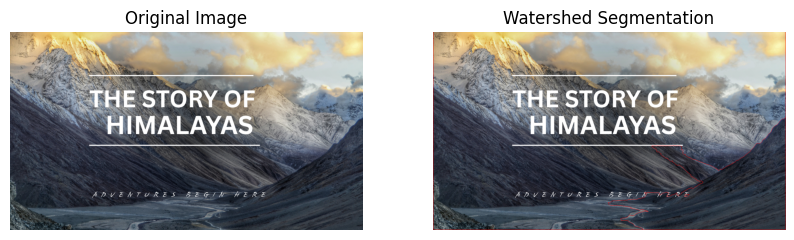

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Read image
img = cv2.imread("/content/Hinalayass.png")
original = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
_, thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    thresh, cv2.MORPH_OPEN, kernel, iterations=2
)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Sure foreground area
dist_transform = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)
_, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels
markers = markers + 1

# Mark unknown region with 0
markers[unknown == 255] = 0

# Apply Watershed
markers = cv2.watershed(img, markers)

# Boundary marked in red
img[markers == -1] = [0, 0, 255]

# Display result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")

plt.show()

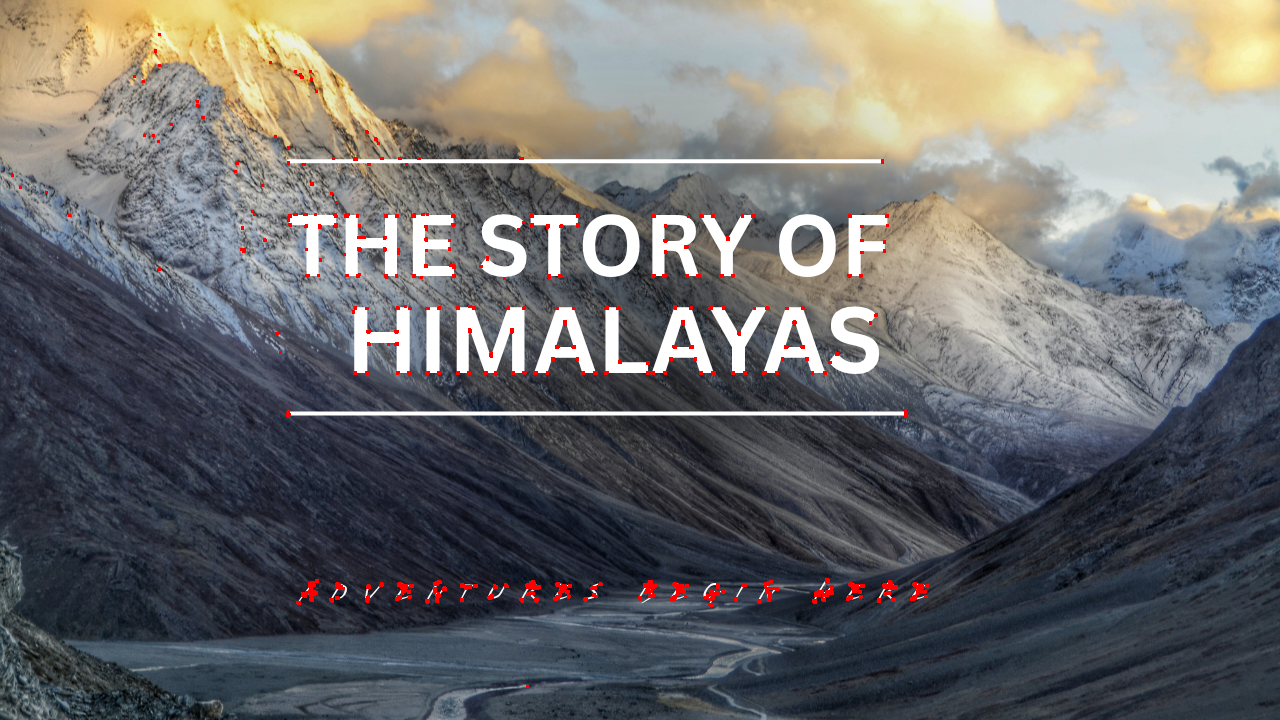

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread("/content/Hinalayass.png")

# Check if image loaded
if img is None:
    print("Image not found!")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    # Harris Corner Detection
    corners = cv2.cornerHarris(gray, 2, 3, 0.04)

    # Dilate corners
    corners = cv2.dilate(corners, None)

    # Mark corners in red
    img[corners > 0.01 * corners.max()] = [0, 0, 255]

    # Display result
    cv2_imshow(img)

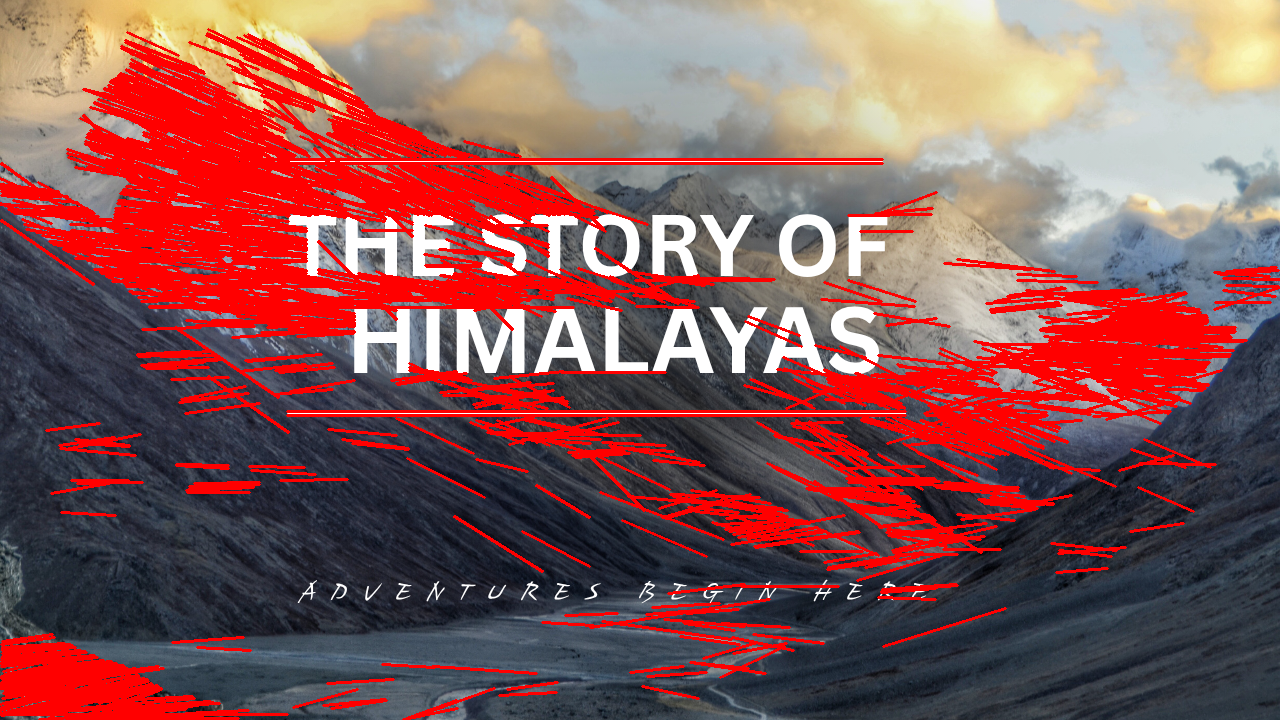

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread("/content/Hinalayass.png")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect edges using Canny
edges = cv2.Canny(gray, 50, 150)

# Apply Hough Line Transform
lines = cv2.HoughLinesP(
    edges,
    1,                # Distance resolution
    np.pi/180,        # Angle resolution
    100,              # Threshold
    minLineLength=50,
    maxLineGap=10
)

# Draw detected lines
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Display result
cv2_imshow(img)